In [1]:
### IMPORT EXTERNAL FUNCTIONS
import mne
import numpy as np
from os.path import join
import os
import pandas as pd
import matplotlib.pyplot as plt
from mne.preprocessing import ICA, read_ica
from mne_icalabel import label_components
from collections import defaultdict
import scipy

### IMPORT OWN FUNCTIONS
# import sys
# from pathlib import Path
# parent_dir = Path.cwd().parent
# sys.path.append(str(parent_dir))
from functions.hampel import hampel_filter, plot_hampel_filter1, plot_hampel_filter2
from functions import utils
from functions import hampel

## Load dataset (SINGLE BLOCK) and prepare for preprocessing

- Load one raw EEG block and the corresponding impedance files (NOTE: impedance comes from full session, not just the single block)
- Remove unnecessary channels and set channel types for EOG and ECG
- Apply 10-20 montage to EEG recording 

In [2]:
session_id = "sub027 DBS ON mSST"
block_num = "block3"

# Paths personal comp.
#data_path = "/Users/charlotte/Library/CloudStorage/OneDrive-Charité-UniversitätsmedizinBerlin/WP3 Task Force/DATA"
#saving_path = "/Users/charlotte/Library/CloudStorage/OneDrive-Charité-UniversitätsmedizinBerlin/phd_charite/WP3/eeg_output/single_sub"
# Paths work. comp. 
# data_path = "C:\\Users\\chst14\\OneDrive - Charité - Universitätsmedizin Berlin\\WP3 Task Force\\DATA"
working_path = os.path.dirname(os.getcwd())
onedrive_path = utils._get_onedrive_path()
saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\eeg_output\\single_sub"

# Set saving paths for figures and preprocessed data
sub = session_id.split(' ') [0]
if "C" in session_id:
    condition = "noDBS"
else:
    condition = session_id.split(' ') [1] + ' ' + session_id.split(' ') [2]

sub_save_path = join(saving_path, sub, condition, "preprocessing", "figures")
os.makedirs(sub_save_path, exist_ok=True)  # Create the directory if it doesn't exist

sub_save_path_icaFigs = join(saving_path, sub, condition, "preprocessing", "figures", "ica")
os.makedirs(sub_save_path_icaFigs, exist_ok=True)  # Create the directory if it doesn't exist

stft_saving_path = join(saving_path, sub, condition, "preprocessing", "figures", "stft_cleaned")
os.makedirs(stft_saving_path, exist_ok=True)  # Create the directory if it doesn't exist

save_path = os.path.join(saving_path, sub, condition, "preprocessing", "data")
os.makedirs(save_path, exist_ok=True)  # Create the directory if it doesn't exist

# # Load impedance files to note potential bad channels
# if "C" in session_id:
#     imp_folder = join(data_path, sub, 'raw_data', 'XDF')
# else:
#     imp_folder = join(data_path, sub, 'raw_data', 'XDF', condition)
# imp_files = [f for f in os.listdir(imp_folder) if (
#     f.endswith('.txt') and f.startswith('MID_impedances'))]
# file_begin = join(imp_folder, imp_files[0])
# file_end = join(imp_folder, imp_files[1])
# imp_begin = pd.read_csv(file_begin, sep='\t', header=None)
# imp_end = pd.read_csv(file_end, sep='\t', header=None)
# imp_begin.drop(2, axis=1, inplace=True)  
# imp_end.drop(2, axis=1, inplace=True)
# # merge the two impedance files on channel names
# imp = imp_begin.merge(imp_end, on=0, how='outer', suffixes=('_begin', '_end'))
# # remove all rows starting with 'UNI'
# imp = imp[~imp[0].str.startswith('UNI')]

# # flag channels with impedance above 25 kOhm:
# high_imp_channels = imp[(imp['1_begin'] > 25) | (imp['1_end'] > 25)]
# if not high_imp_channels.empty:
#     print("Channels with high impedance (> 25 kOhm):")
#     print(high_imp_channels, "\n")
# else:
#     print("No channels with high impedance found. \n")

# also load the two impedance files to check channels briefly
impedance_folder = join(onedrive_path, sub, 'raw_data', 'XDF', condition)
impedance_begin_filename = [f for f in os.listdir(impedance_folder) if (
    f.endswith('.txt') and f.startswith('mSST_impedances_begin'))]
impedance_end_filename = [f for f in os.listdir(impedance_folder) if (
    f.endswith('.txt') and f.startswith('mSST_impedances_end'))]
file_begin = join(impedance_folder, impedance_begin_filename[0])
file_end = join(impedance_folder, impedance_end_filename[0])
impedance_begin = pd.read_csv(file_begin, sep='\t', header=None)
impedance_end = pd.read_csv(file_end, sep='\t', header=None)
impedance_begin.drop(2, axis=1, inplace=True)  
impedance_end.drop(2, axis=1, inplace=True)
imp = impedance_begin.merge(impedance_end, on=0, how='outer', suffixes=('_begin', '_end'))
# remove all rows starting with 'UNI':
imp = imp[~imp[0].str.startswith('UNI')]

# flag channels with impedance above 25 kOhm:
high_imp_channels = imp[(imp['1_begin'] > 25) | (imp['1_end'] > 25)]
if not high_imp_channels.empty:
    print("Channels with high impedance (> 25 kOhm):")
    print(high_imp_channels)
else:
    print("No channels with high impedance found.")


# Load EEG raw block
sub_data_path = join(saving_path, sub, condition, 'raw_blocks')
block_files = os.listdir(sub_data_path)

for file in block_files:
    if block_num in file:
        curr_block = file
        block_to_load = join(sub_data_path, curr_block)
        raw = mne.io.read_raw(block_to_load, preload=True)    


# Print sampling frequency
sf = raw.info['sfreq']
print(f"Sampling frequency: {sf} Hz \n")

# Drop channels that won't be used, set channel types, and set montage
raw.drop_channels(['CREF', 'X', 'Y', 'Z', 'TRIGGERS', 'STATUS', 'COUNTER', 'BIP 01'])
raw.set_channel_types({'BIP 02': 'ecg', 'BIP 03': 'eog'}) 

# 10-20 montage
data = raw.set_montage('standard_1020', match_case=False, match_alias=True, on_missing='warn') 
ch_names = data.ch_names



No channels with high impedance found.
Opening raw data file C:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block3_raw.fif...
Isotrak not found
    Range : 2452257 ... 3246428 =   1197.402 ...  1585.184 secs
Ready.
Reading 0 ... 794171  =      0.000 ...   387.782 secs...
Sampling frequency: 2047.9815673828125 Hz 



In the above output, we can double check that the "Range" corresponds to the correct timings for the block we are trying to load. 

## Plot raw PSD

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


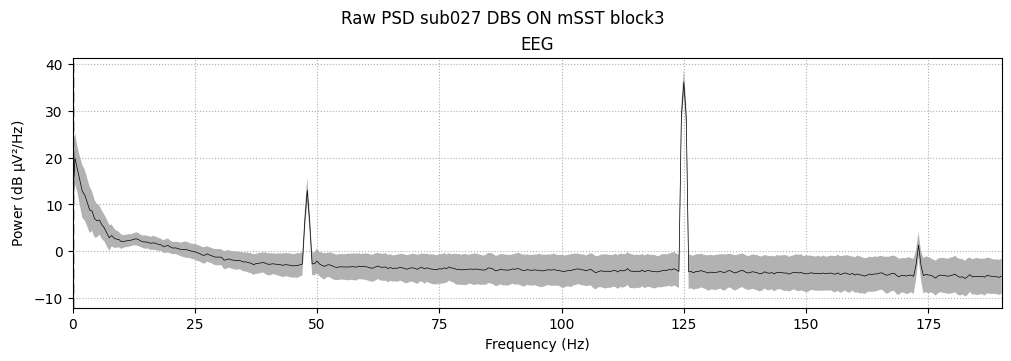

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


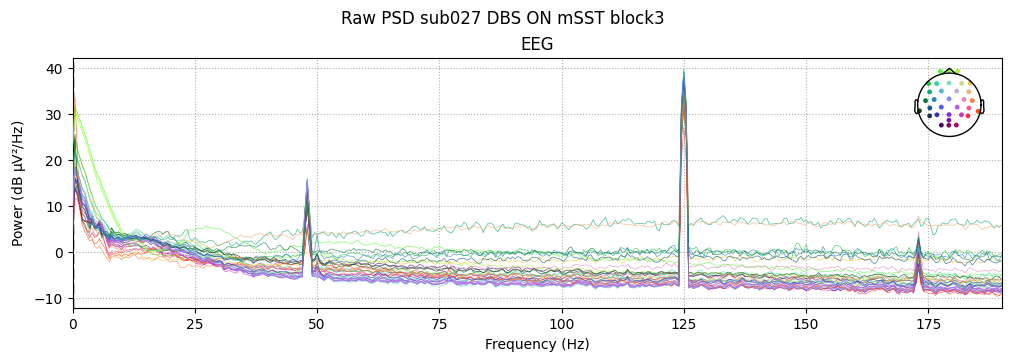

In [3]:
%matplotlib inline
# sf = 2048 Hz, n_fft = 4096 ⇒ 2.0 s segments/window, n_overlap = 2048 (50%)
# freq res = 0.5 Hz -> n_fft = 4096 at sf = 2048 Hz

### Plot PSD of signal (averaging all channels)
psd_raw_avg = data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=190, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_raw_avg.plot(dB=True, average=True).suptitle(f"Raw PSD {session_id} {block_num} ")
plt.show()

### Plot PSD of signal (not averaging)
psd_raw = data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=190, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_raw.plot(dB=True, average=False).suptitle(f"Raw PSD {session_id} {block_num} ")
plt.savefig(join(sub_save_path, f"{session_id}_{block_num}_raw_PSD_avg.png"), dpi=300)
plt.show()

## Plot raw data

In [ ]:
raw.plot()

## Filter the data

- Apply high-pass filter at 1Hz to remove slow drifts.
- Apply low-pass filter at 100Hz to remove DBS artefact and keep frequencies of interest for further analyses.
- Apply notch filter at 50Hz to remove line noise.

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 6759 samples (3.300 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 271 samples (0.132 s)



[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 13517 samples (6.600 s)



[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 2.000 (s)


[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.9s finished


Plotting power spectral density (dB=True).


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


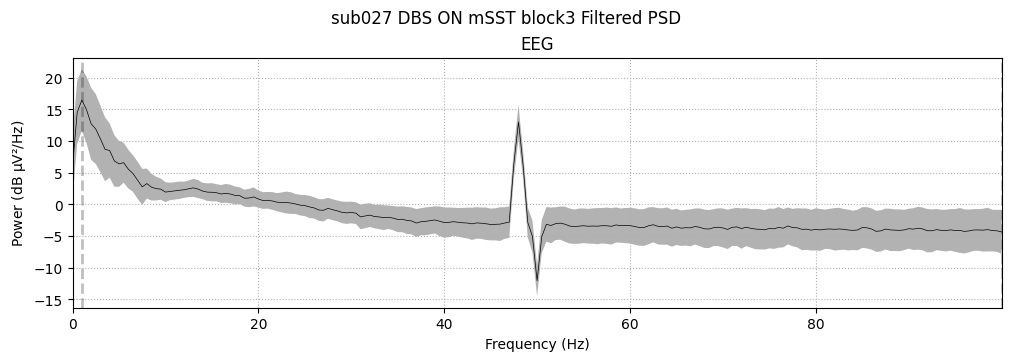

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


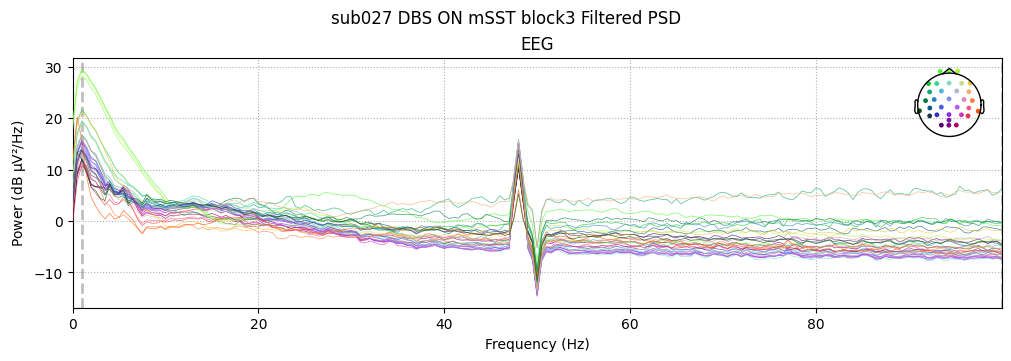

In [3]:
# first apply 1Hz high pass filter
high_passed_filt_eeg_data = data.copy().filter(1, None) 

# then apply 100Hz low pass filter
high_low_passed_filt_eeg_data = high_passed_filt_eeg_data.copy().filter(None, 100)  # use 100Hz low-pass for all sub, except sub stimulated at 85Hz

# Last, apply notch filter
# Even if 50Hz activity is not present in the raw, it is sometimes present after re-referencing. 
# Therefore, safer to apply a notch filter at 50Hz for all sessions.
filt_eeg_data = high_low_passed_filt_eeg_data.copy().notch_filter(50) 


%matplotlib inline

# freq res = 0.5 Hz -> n_fft = 4096 at sf = 2048 Hz

### Plot PSD of signal (averaging all channels)
psd_filt_avg = filt_eeg_data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=100, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_filt_avg.plot(dB=True, average=True).suptitle(f"{session_id} {block_num} Filtered PSD")
plt.show()

### Plot PSD of signal (not averaging)
psd_filt = filt_eeg_data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=100, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_filt.plot(dB=True, average=False).suptitle(f"{session_id} {block_num} Filtered PSD")
plt.show()


## IF artefactual peaks -> Hampel filtering

### else skip to bad channel detection + interpolation 
e.g. in our recordings at 2048Hz, we commonly see a peak at 48Hz coming from the aliasing of the 16th harmonic of 125Hz DBS 

In [4]:
## Get channel time courses
tc = filt_eeg_data.get_data(picks='eeg') # Ephys channel time courses
tc.shape

(32, 794172)

#### Input parameters

- **stft_win:** window length for STFT. Longer window improves frequency resolution, makes time resolution worse. Because we are using it to remove stimulation harmonics, time resolution is not critical so we want to focus on frequency resolution. 60 sec default value.

- **mov_win:** sliding window defines how many neighbouring freqs are used as reference when deciding whether a freq bin is an outlier. Makes outlier detection local rather than global, harmonic peaks stand out more clearly. Default value: 3.

- **c_val:** threshold for outlier detection. Larger values (e.g., 6-8Hz) is conservative and only extreme peaks are detected. Lower thresholds (e.g., 3-4) is more aggressive and more peaks can be detected. Because the stimulation harmonics are strong peaks, we can be conservative. Default value: 6.

In [7]:
import importlib

In [10]:
from functions import hampel

In [11]:
importlib.reload(hampel)

<module 'functions.hampel' from 'c:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\scripts\\functions\\hampel.py'>

In [5]:
stft_win = 60 
mov_win = 3
c_val = 6

# # apply hampelfilter ATTENUATION method
# tc_cleaned =  hampel_filter(tc, raw.info['sfreq'], cleaning_method='attenuation', sftf_window=stft_win, moving_window=mov_win, cval=c_val, frequency_range=[[40,60], [65,90]])

# apply hampelfilter MEDIAN method
tc_cleaned =  hampel_filter(tc, raw.info['sfreq'], cleaning_method='median', sftf_window=stft_win, moving_window=mov_win, cval=c_val, frequency_range=[[40,60], [65,90]])
    

Parameter selection allows STFT to be inverted.
Zxx shape: (32, 61440, 14)
Outliers detected at frequencies: [0.00000000e+00 1.66667879e-02 3.33335759e-02 ... 1.00134062e+03
 1.00135729e+03 1.00137395e+03] Hz
Outliers retained after frequency range masking: [47.95034888 47.96701567 47.98368245 48.00034924 48.01701603 48.03368282
 48.05034961 77.00056024 77.01722703 87.98397349] Hz
Starting outlier cleaning with method: median
Outliers.shape: (61440,)
Finished median interpolation (outlier frequencies only).
Combining real and imaginary parts into cleaned frequency data.
Testing cleaned data for remaining outliers.
Projecting cleaned frequency data back to time courses with inverse STFT.
Finished projecting cleaned data back to time courses.


In [6]:
picks_eeg = mne.pick_types(filt_eeg_data.info, eeg=True, exclude=())

final_filtered_eeg = filt_eeg_data.copy().load_data()
final_filtered_eeg._data[picks_eeg, :] = tc_cleaned

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


<Figure size 800x400 with 0 Axes>

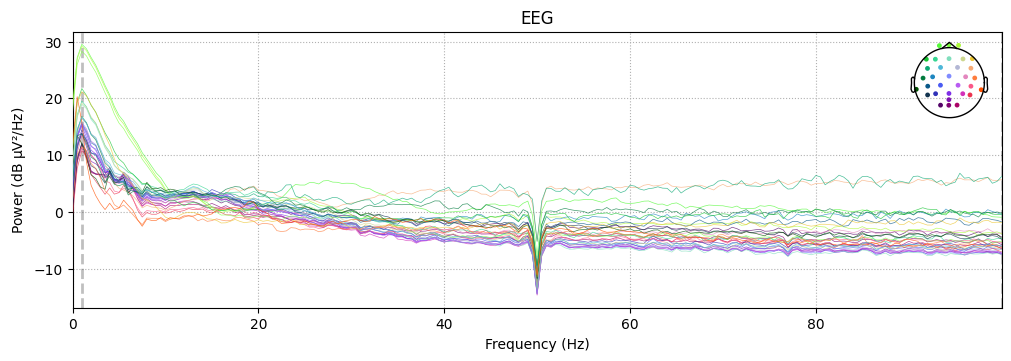

In [7]:
# Plot PSD of signal
plt.figure(figsize=(8, 4))
fig = final_filtered_eeg.plot_psd(
    method="welch",
    picks="eeg",
    fmax=100,
    n_fft=round(sf)*2,
    n_overlap=int(round(sf)),
    window="hamming",
    dB=True,
    average=False
)

plt.show()

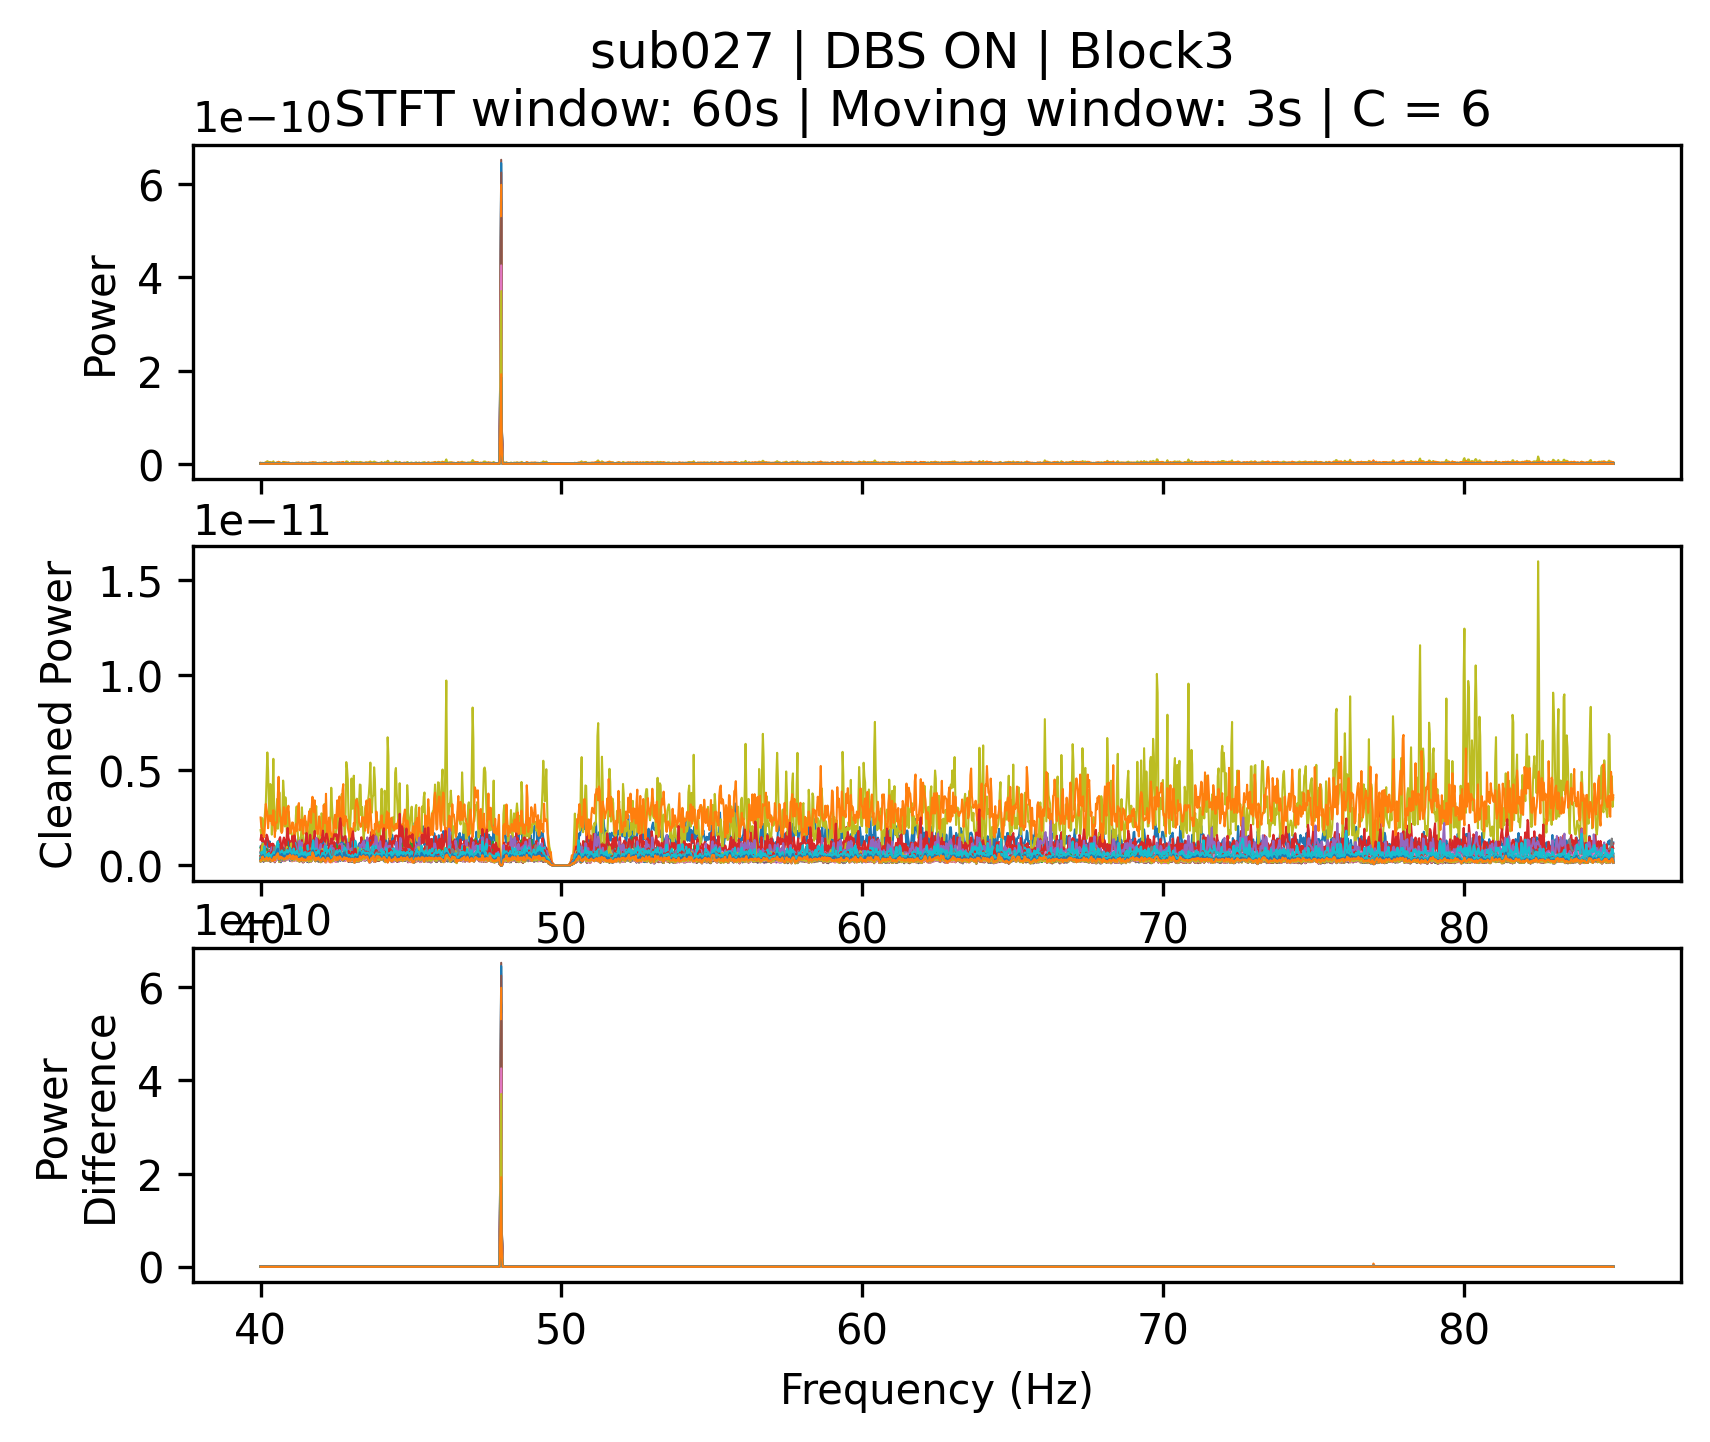

In [8]:
# Plot Results to check whether Hampel Filter did something reasonable
# Make Overview Plot1
fig1 = plot_hampel_filter1(tc, tc_cleaned, raw.info['sfreq'], freq_range=[40,85])

title_main = f"{sub} | {condition} | {block_num.capitalize()}"
title_sub = f"STFT window: {stft_win}s | Moving window: {mov_win}s | C = {c_val}"
fig1.suptitle(title_main + "\n" + title_sub, fontsize=12)
fig1.subplots_adjust(top=0.90)

fig1.savefig(join(sub_save_path, f"{sub}_{condition}_{block_num}_hampel_filter_overview1.png"), dpi=300)
plt.show()


NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.8s finished


NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 4.000 (s)


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Plotting power spectral density (dB=True).


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.3s finished


NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.3s finished


NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.5s finished
C:\Users\Juliette\AppData\Local\Temp\ipykernel_14780\2255156219.py:12: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig2.subplots_adjust(top=0.90)


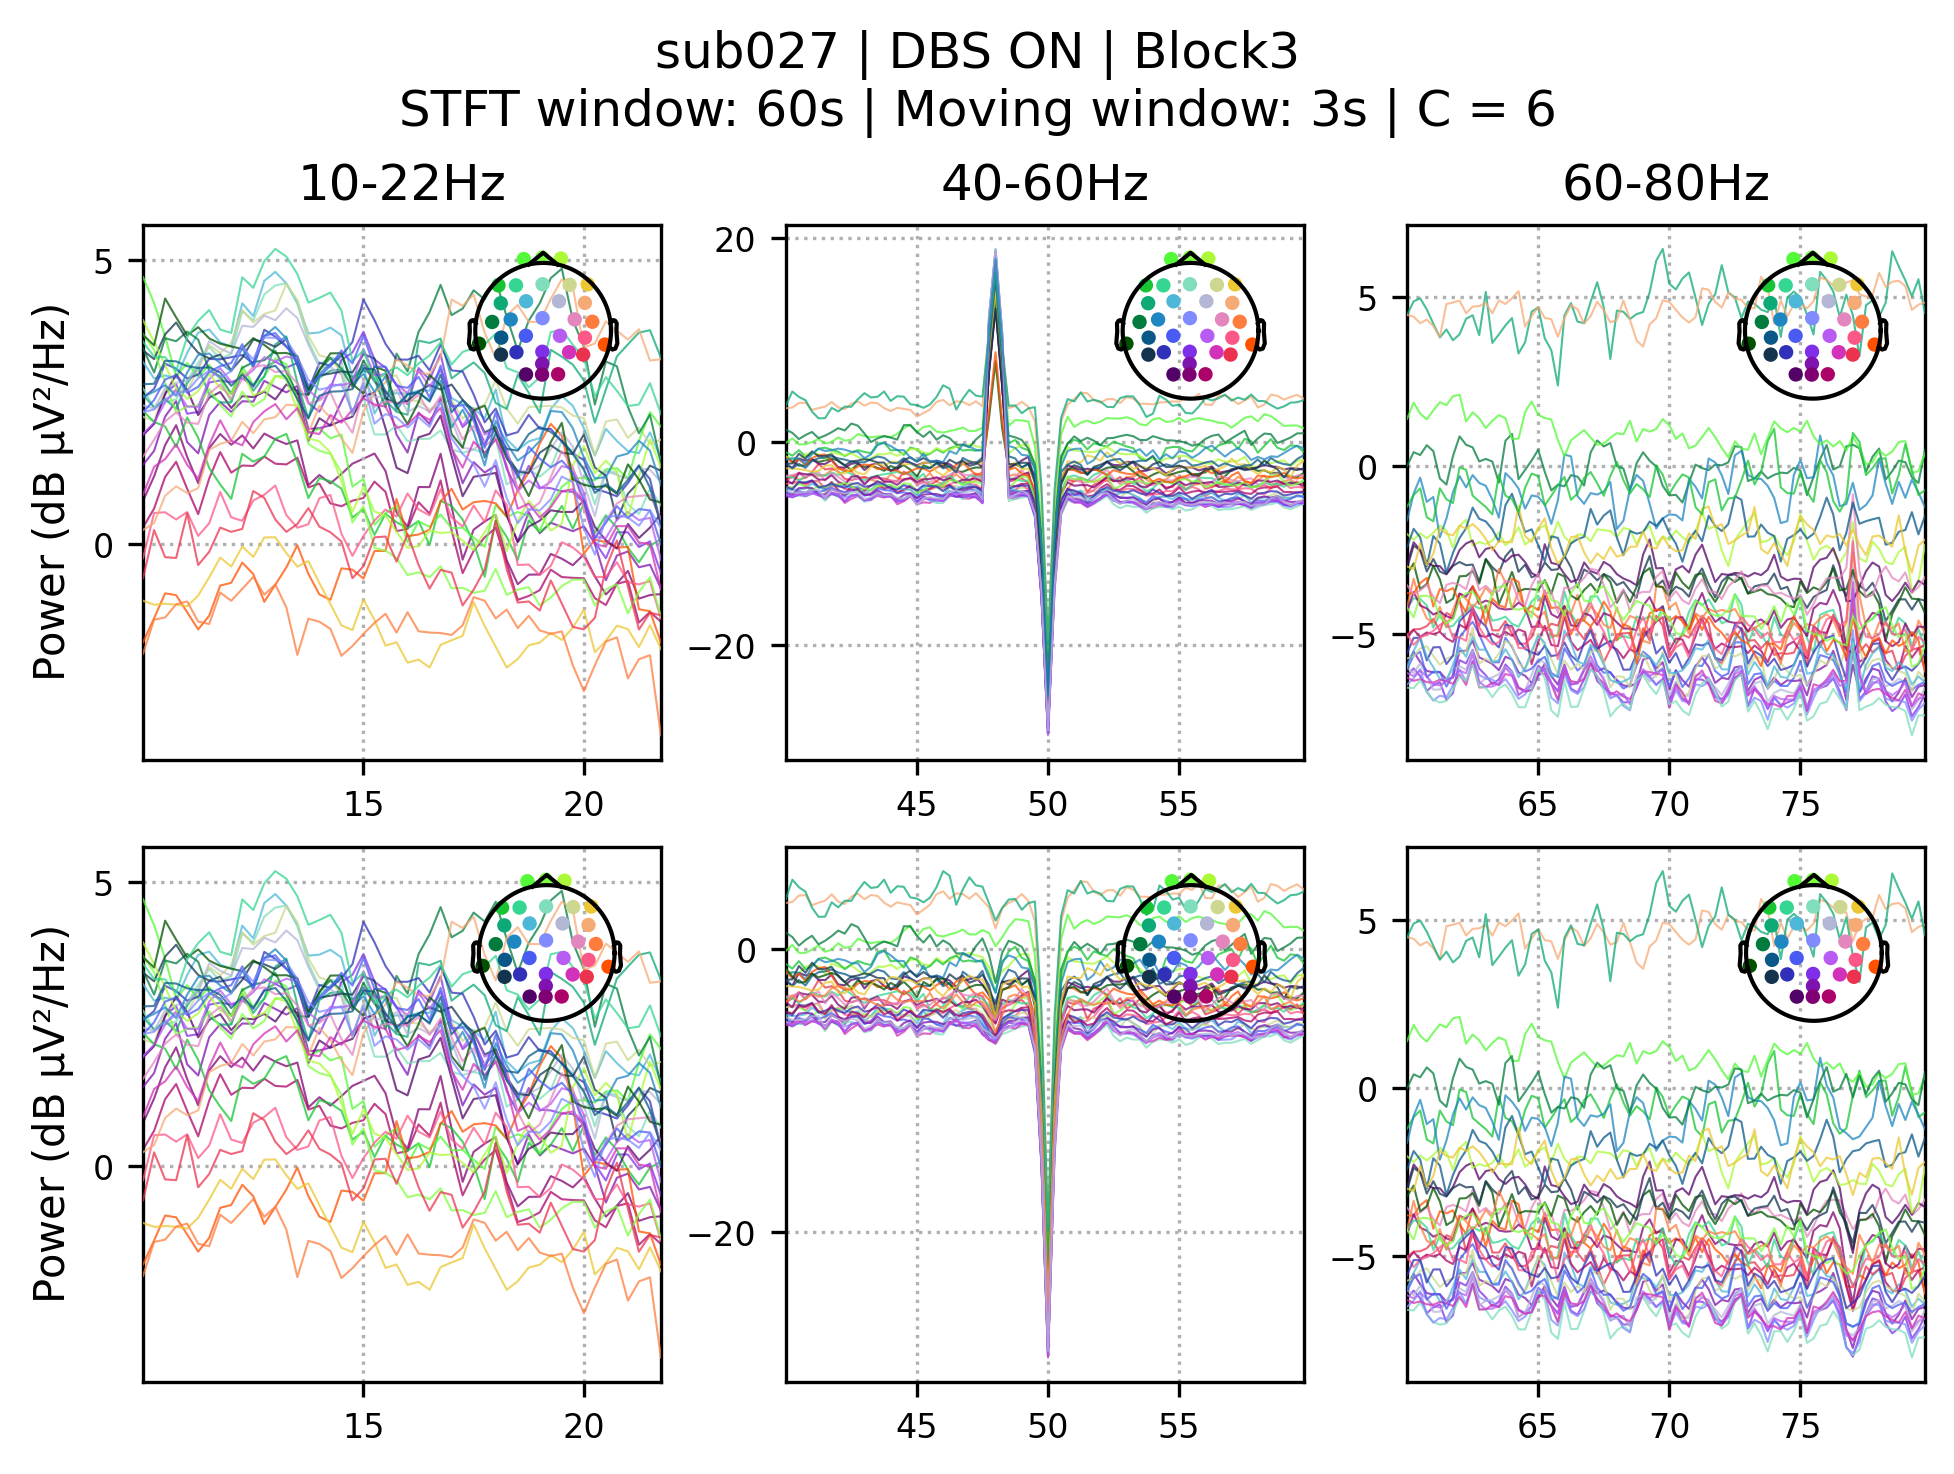

In [9]:
# Make Overview Plot2
# Power Spectrum Parameters
n_fft = int(4*raw.info['sfreq'])  # 4 second segments
n_overlap = int(2*raw.info['sfreq'])
## Can also set n_fft and overlap to 1

fig2 = plot_hampel_filter2(filt_eeg_data, final_filtered_eeg, freq_ranges=[[10,22],[40,60], [60,80]], ephys_chans='eeg', n_fft=n_fft, n_overlap=n_overlap)

title_main = f"{sub} | {condition} | {block_num.capitalize()}"
title_sub = f"STFT window: {stft_win}s | Moving window: {mov_win}s | C = {c_val}"
fig2.suptitle(title_main + "\n" + title_sub, fontsize=12)
fig2.subplots_adjust(top=0.90)

fig2.savefig(join(sub_save_path, f"{sub}_{condition}_{block_num}_hampel_filter_overview2.png"), dpi=300)
plt.show()



## Identify and interpolate bad channels, before re-referencing to average

- Get a first idea of "bad" channels using automatic classification (see details below)

- Plot data and go through full recording session
    - Check channels flagged in automatic detection if bad or not
    - If necessary mark other bad channels

- Interpolate the bad channels

- Re-reference to average

### "Automatic" detection of bad channels through Z-scoring and looking at SD and variance in freq and time domain

**PSD_Z:**
- Computes each channel’s average power (1–80 Hz) in dB, then z-scores across channels—so it flags electrodes whose overall spectral “bulk” is unusually high or low (e.g., a consistently noisy or dead contact) (A single value per channel, tells us whether the channel is generally noisier or quieter than the others) (looks at Frequency domain).

**P2P_Z:**
- Measures the maximum 250 ms peak-to-peak excursion per channel and z-scores those values—so it catches electrodes with extreme transients (cable pops, big spikes) or abnormally flat signals (looks at Time domain)
(Takes the highest voltage the channel reaches minus the lowest voltage it reaches—that difference is its peak-to-peak value.)

**Corr_Z:**
- Computes each channel’s mean Pearson correlation to all other channels, then z-scores—so it flags sensors that aren’t co-varying with the head (e.g., drifty or disconnected channels, channels that don't correlate with their neighbours).

**Var_Z:**
- Takes each channel’s overall variance and z-scores—so it highlights electrodes that are unusually “spiky” or “quiet” over the whole recording (looks at Time domain).

**Max_Freq_Z:**
- Looks for the largest per-frequency deviation (in z-units) from the grand mean spectrum—so it catches narrowband bursts (line-noise leakage, muscle peaks) that might be lost in the broad PSD average (=For each frequency bin look at how many SD above/below the across-channel mean power that channel’s power is at that exact frequency (i.e. a z-score at 10 Hz, at 20 Hz, etc.), and take whichever of those frequency-specific z-scores is largest in absolute value. That way, even if a channel’s overall PSD looks okay, a single narrowband spike (say a 50 Hz line-noise leak or a muscle peak at 80 Hz) will make its “max_freq_z” jump out.) (looks at Frequency domain).

#### Rule of thumb:
- If it fails two or more of the checks, probably bad - but do a visual check of PSD and raw trace
- Failing one check: Look at PSD and raw trace - if looking good, keep it in

**NOTE** Frontal channels can often be flagged, but that is likely because of eyeblinks, so don't necessarily remove them if the raw trace itself looks ok besides the eyeblink!

In [ ]:
%matplotlib qt

# If Hampel filter was not applied the variable does not exist,
# so we set final_filtered_eeg to filt_eeg_data
try:
    final_filtered_eeg
except NameError:
    final_filtered_eeg = filt_eeg_data.copy()

# rename for readability
bad_chan_identifier = final_filtered_eeg.copy().drop_channels(['Fp1', 'Fpz', 'Fp2']) # drop frontal channels because they are often noisy due to eye blinks and this affects the mean/variance computed

# pick only the EEG channels that aren’t already in raw.info['bads']
picks = mne.pick_types(bad_chan_identifier.info, meg=False, eeg=True, exclude='bads')

sfreq = bad_chan_identifier.info['sfreq']
    
# Frequency-domain PSD checks
psd_container = bad_chan_identifier.compute_psd(method="welch", picks="eeg", fmin=0, fmax=100, n_fft=round(sfreq)*2, n_overlap=int(round(sfreq)), window="hamming")

# Convert to dB and compute mean PSD per channel
psds     = psd_container.get_data()     # (n_picks, n_freqs)
psd_db   = 10 * np.log10(psds)
mean_psd = psd_db.mean(axis=1)
psd_z    = (mean_psd - mean_psd.mean()) / mean_psd.std()

# Peak-to-peak amplitude in 250 ms windows
data = bad_chan_identifier.get_data(picks=picks)     # (n_picks, n_times)
win_samp = int(0.25 * sfreq)
n_win    = data.shape[1] // win_samp
p2p_mat  = np.zeros((len(picks), n_win))
for w in range(n_win):
    seg = data[:, w*win_samp:(w+1)*win_samp]
    p2p_mat[:, w] = seg.max(axis=1) - seg.min(axis=1)
max_p2p = p2p_mat.max(axis=1)
p2p_z   = (max_p2p - max_p2p.mean()) / max_p2p.std()

# Channel–channel correlation 
corr      = np.corrcoef(data)
mean_corr = corr.mean(axis=0)
corr_z    = (mean_corr - mean_corr.mean()) / mean_corr.std()

# Compute time-domain variance per channel and z-score
# Flags channels with too much or too little amplitude variability over the rec (relative to the other electrodes),
# i.e., it could be flat or very spiky
chan_vars = np.var(data, axis=1)
var_z     = (chan_vars - chan_vars.mean()) / chan_vars.std()

# Compute frequency-wise z-scores and max deviation per channel
# Looks for channels which have high spikes in some frequencies, could indicate e.g., line noise or muscle artefact
mean_freq   = psd_db.mean(axis=0)
std_freq    = psd_db.std(axis=0)
freq_z      = (psd_db - mean_freq) / std_freq
max_freq_z  = np.max(np.abs(freq_z), axis=1)

# Threshold all metrics at ±2.5 Z
thresh = 2.5
mask_psd   = np.abs(psd_z)    > thresh
mask_p2p   = np.abs(p2p_z)    > thresh
mask_corr  = corr_z           < -thresh    # flag very low corr (z < -2.5)
mask_var   = np.abs(var_z)    > thresh
mask_freq  = max_freq_z       > thresh

# combine
mask_all = mask_psd | mask_p2p | mask_corr | mask_var | mask_freq
bad_channels = [bad_chan_identifier.ch_names[picks[i]]
                for i, m in enumerate(mask_all) if m]

# Print per-metric flagged channels
print(">> PSD outliers (|z|>2.5):", [bad_chan_identifier.ch_names[picks[i]] for i in np.where(mask_psd)[0]])
print(">> Peak-to-peak outliers (|z|>2.5):", [bad_chan_identifier.ch_names[picks[i]] for i in np.where(mask_p2p)[0]])
print(">> Low-correlation outliers (corr_z < -2.5):", [bad_chan_identifier.ch_names[picks[i]] for i in np.where(mask_corr)[0]])
print(">> Variance outliers (|z|>2.5):", [bad_chan_identifier.ch_names[picks[i]] for i in np.where(mask_var)[0]])
print(">> Spectral‐spike outliers (max_freq_z>2.5):", [bad_chan_identifier.ch_names[picks[i]] for i in np.where(mask_freq)[0]])
print(">> Final flagged channels:", bad_channels)

# Summarize in a DataFrame 
df = pd.DataFrame({
    "Channel":     [bad_chan_identifier.ch_names[p]      for p in picks],
    "PSD_Z":       np.round(psd_z,    2),
    "P2P_Z":       np.round(p2p_z,    2),
    "Corr_Z":      np.round(corr_z,   2),
    "Var_Z":       np.round(var_z,    2),
    "Max_Freq_Z":  np.round(max_freq_z,2),
    "Flagged":     mask_all
})
print(df)

# Visual check: all individual PSDs
bad_chan_identifier.plot_psd(
    fmin=1.0, fmax=100.0,
    picks=picks,
    dB=True,
    average=False,
    show=True
)


## Remove bad channels 
#### Go through full session

In [ ]:
%matplotlib qt

# Plot raw signal
final_filtered_eeg.plot(n_channels = len(ch_names), duration = 20, scalings="auto", block=True) # Cell block waits for plot to be closed before continuing (i.e., saving)

file_p = join(save_path, f"{sub}_{condition}_{block_num}_badChannels_removed_EEGdata_eeg.fif")
final_filtered_eeg.save(file_p, overwrite=True)

In [ ]:
# ensure bad channels are listed here, otherwise they will be included in the average reference
final_filtered_eeg.info['bads']

### Interpolate bad channels

In [ ]:
eeg_data_interp = final_filtered_eeg.copy().interpolate_bads(reset_bads=True)

### Re-reference to average reference

In [ ]:
av_ref_data = eeg_data_interp.copy().set_eeg_reference(ref_channels="average")


## Plot PSD again

In [ ]:
%matplotlib inline

# freq res = 0.5 Hz -> n_fft = 4096 at sf = 2048 Hz

### Plot PSD of signal (averaging all channels)
psd_final_avg = av_ref_data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=100, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_final_avg.plot(dB=True, average=True).suptitle(f"{session_id} {block_num} PSD after re-referencing")
plt.show()

### Plot PSD of signal (not averaging)
psd_final = av_ref_data.compute_psd(method="welch", picks="eeg", fmin=0, fmax=100, n_fft=round(sf)*2, n_overlap=int(round(sf)), window="hamming")
psd_final.plot(dB=True, average=False).suptitle(f"{session_id} {block_num} PSD after re-referencing")
plt.savefig(join(sub_save_path, f"{session_id}_{block_num}_after_reRef.png"))
plt.show()

## Clean artefacts using Independent Component Analysis (ICA)

- Fit ICA to the filtered re-referenced data
    - First we will clean the data, so the ICA is fitted to clean data (and we will apply it to the re-referenced)
- Automatic labelling of "bad" components
    - Using mne-icalabel
    - Using eegprep (from Arnaud Delorme)
- Manual labelling of "bad" components (and comparison with automatic)
- Select which ICA components to exclude and reconstruct the signal without them


**Notes from https://eeglab.org/tutorials/06_RejectArtifacts/RunICA.html:**

"ICA takes all training data into consideration. When too many types (i.e., scalp distributions) of noise - complex movement artifacts, electrode pops, etc – are left in the training data, these unique and irreplicable data features will draw the attention of ICA, producing a set of component maps including many single-channel or noisy-appearing components. The number of components (degrees of freedom) devoted to the decomposition of brain EEG alone will be correspondingly reduced.
Therefore, presenting ICA with as much clean EEG data as possible is the best strategy. Note that blink and other stereotyped EEG artifacts do not necessarily have to be removed since they are likely to be isolated as single ICA components.
Here clean EEG data means data after removing noisy time segments (does not apply to removed ICA components)." --> hence, remove breaks before runnning ICA

**Random note:**

When cognitive load increases, blinking usually decreases. Because when participants are expecting something important to happen (stimulus appearance), they will unconsciously try not to blink, to pay more attention (source: https://www.youtube.com/watch?v=AXCxrDikpaM)

### Clean the data by annotating bad segments (movement)

In [ ]:
%matplotlib qt
av_ref_data2 = av_ref_data.copy()
# Plot signal and annotate bad segments to fit the ICA only on the parts that are the most clean
av_ref_data2.plot(n_channels = len(ch_names), duration = 20, scalings="auto", block=True) # block = True -> Cell block waits for plot to be closed before continuing

### Fit ICA
Here we use the extended infomax method, because it is the preferred method for mne-icalabel automatic classification.

In [ ]:
# Store the fitted or loaded ICA objects
ica_fit_dict = {}
 
# Construct the file path for the ICA file
ica_file_path = join(save_path, f"{sub}-{condition}_{block_num}-ica.fif")
    
# # Check if the ICA file exists
#if os.path.exists(ica_file_path):
#     # If it exists, load the ICA object
#     ica = read_ica(ica_file_path)
#     print(f"Loaded ICA for {sub} from {ica_file_path}")

# else:
# If it doesn't exist, fit ICA to the data
ica = ICA(n_components=None, random_state=11, method='infomax', fit_params=dict(extended=True)) # Number of components is chosen by function to account for 99%
ica.fit(av_ref_data2.pick_types(eeg=True), reject_by_annotation=True)                                  
                         

# Save the ICA object to file (saving the ICA decomposition, not any raw/cleaned data)
ica.save(ica_file_path, overwrite=True)
print(f"Fitted and saved ICA for {session_id} at {ica_file_path}")
    
ica_fit_dict = ica

for i in range(ica.n_components_):
    fig = ica_fit_dict.plot_properties(picks=[i], inst=av_ref_data2, show=False) # Topographies of each component
    plt.savefig(join(sub_save_path_icaFigs, f"{session_id}_{block_num}_ica_component_{i}.png"), dpi=300)
    plt.close()


### Automatic labelling using mne-icalabel

In [ ]:
%matplotlib inline
# Get automatic classification labels for ICA components using mne-icalabel package (pip install mne-icalabel) to get a first idea
ic_labels = label_components(av_ref_data2, ica, method="iclabel")
labels = ic_labels["labels"]
mne_icalabel_excluded = [
    idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
]
mne_icalabel_labels = [
    (idx, label) for idx, label in enumerate(labels)
]
print(f"Excluding these ICA components: {mne_icalabel_excluded}")

ica.plot_properties(av_ref_data, picks=mne_icalabel_excluded, verbose=False)

'eye blink',
'muscle artifact', 

In [ ]:
mne_icalabel_labels

### Manual labelling of ICA components

#### Plot components

In [ ]:
%matplotlib qt

fig = ica.plot_components(inst=av_ref_data2,  psd_args={'fmin': 0, 'fmax': 90}, ncols=6, nrows=6) #Topographies of each component
plt.savefig(join(sub_save_path_icaFigs, f"{sub}_{condition}_{block_num}_ica_components.png"), dpi=300)

#### Plot source timeseries

In [ ]:
%matplotlib qt

fig_sources = ica.plot_sources(av_ref_data2) # Timeseries of each ICA component

#### Select components to exclude

In [ ]:
to_exclude = mne_icalabel_excluded.copy() # copy the list of automatically identified components  to exclude

to_exclude.remove(2) # remove components if you think they are brain components after visual inspection
to_exclude.remove(3)
to_exclude.remove(7)
to_exclude.remove(10)
to_exclude.remove(25)
to_exclude.remove(28)

to_exclude.extend([17]) # add any other components you want to exclude after visual inspection


In [ ]:
to_exclude = [0, 2]

In [ ]:
### Check that the correct components are being excluded
to_exclude

#### Apply ICA to the re-referenced data + exclude selected components

In [ ]:
data_after_ica = ica.apply(av_ref_data.copy(), exclude=to_exclude)

## Visual inspection and saving after preprocessing

In [ ]:
%matplotlib qt
data_after_ica.plot(scalings="auto", title="After ICA")

In [ ]:
%matplotlib inline

### Plot PSD of signal (not averaging)
psd_after_ica = data_after_ica.compute_psd(method="welch", picks="eeg", fmin=0, fmax=85, n_fft=round(sf)*2, n_overlap=0, window="hamming")
psd_after_ica.plot(dB=True, average=False).suptitle(f"{session_id} {block_num} PSD after ICA")
plt.savefig(join(sub_save_path, f"{sub}_{condition}_{block_num}_after_ICA_PSD.png"), dpi=300)
plt.show()

### Save 

In [ ]:
# Save
file_p = join(save_path, f"{sub}_{condition}_{block_num}_postICA_EEGdata_eeg.fif")
data_after_ica.save(file_p, overwrite=True)


## Visualise STFT of each channel

In [ ]:
%matplotlib inline

raw_plotting = data_after_ica

# Work with EEG picks and aligned names
eeg_picks = mne.pick_types(raw_plotting.info, eeg=True, eog=False, stim=False, misc=False, ref_meg=False)
eeg_ch_names = [raw_plotting.info['ch_names'][i] for i in eeg_picks]

# Exclude channels 
exclude = {'BIP 02', 'BIP 03'}
plot_names = [nm for nm in eeg_ch_names if nm not in exclude]

# 3) Map channel name -> row index in eeg_data
name_to_idx = {nm: i for i, nm in enumerate(eeg_ch_names)}

# 4) Grab EEG data once
eeg_data = raw_plotting.get_data(picks=eeg_picks)
sfreq = raw_plotting.info['sfreq']

vmin, vmax = -17, -13

for ch in plot_names:
    ch_index = name_to_idx[ch]

    f, t, Zxx = scipy.signal.stft(
        eeg_data[ch_index, :], raw_plotting.info['sfreq'], nperseg=int(round(raw_plotting.info['sfreq'])), noverlap=int(round(raw_plotting.info['sfreq']) / 2), nfft=int(round(raw_plotting.info['sfreq']))
    )
    Pxx = np.abs(Zxx)
    plt.figure(figsize=(10, 4))
    im = plt.imshow(np.log(Pxx), aspect='auto', origin='lower',
                            extent=[t[0], t[-1], f[0], f[-1]], cmap='viridis',
                            vmin=vmin, vmax=vmax)
    plt.ylim(0,100)
    plt.colorbar()
    plt.xlabel('Time [sec]')
    plt.ylabel('Frequency [Hz]')
    plt.title(f'{session_id} {block_num} - EEG - {ch}')
    plt.savefig(os.path.join(stft_saving_path, f"{session_id}_{block_num}_{ch}_STFT.png"))
    plt.show()

## Extract epochs for quick visual check (TFR + ERPs)

In [ ]:
# If preprocessing has already been done, load the data_after_ica file
file_p = join(save_path, f"{sub}_{condition}_{block_num}_postICA_EEGdata_eeg.fif")
data_after_ica = mne.io.read_raw_fif(file_p, preload=True)


In [ ]:
from functions import preprocessing

In [ ]:
mSST_raw_behav_session_data_path = join(
        onedrive_path, sub, "raw_data", 'BEHAVIOR', condition, 
        'mSST'
        )
for filename in os.listdir(mSST_raw_behav_session_data_path):
        if filename.endswith(".csv"):
            fname = filename
filepath_behav = join(mSST_raw_behav_session_data_path, fname)
df = pd.read_csv(filepath_behav)

# return the index of the first row which is not filled by a Nan value:
start_task_index = df['blocks.thisRepN'].first_valid_index()
stop_task_index = df['blocks.thisRepN'].last_valid_index()
df_maintask = df.iloc[start_task_index:stop_task_index + 1]

# only keep trials of the block we are analyzing
block_num_int = int(block_num.replace('block', ''))
print(block_num_int)
df_maintask = df_maintask[df_maintask['blocks.thisN'] == (block_num_int - 1)].reset_index(drop=True)
print(df_maintask.shape)

# remove all useless columns to clean up dataframe
column_names = df_maintask.columns
columns_to_keep = [i for i in [
    'blocks.thisN', 'trial_loop.thisN', 'trial_type', 
    'continue_signal_time', 'stop_signal_time', 
    'fixation_cross.started', 'go_rectangle.started',
    'key_resp_experiment.keys', 'key_resp_experiment.corr', 'key_resp_experiment.rt',
    'early_press_resp.keys', 'early_press_resp.rt', 'early_press_resp.corr',
    'late_key_resp1.keys', 'late_key_resp1.rt', 
    'late_key_resp2.keys', 'late_key_resp2.rt'
    ] if i in column_names]

mini_df_maintask = df_maintask[columns_to_keep]
print(mini_df_maintask.shape)

# remove the trials with early presses, as in these trials the cues were not presented (for mSST)
early_presses = mini_df_maintask[mini_df_maintask['early_press_resp.corr'] == 1]
early_presses_trials = list(early_presses.index)
number_early_presses = len(early_presses_trials)
print(f'Number of early presses: {number_early_presses}')

# remove trials with early presses from the dataframe:
df_maintask_copy = mini_df_maintask.drop(early_presses_trials).reset_index(drop=True)
print(df_maintask_copy.shape)
print(df_maintask_copy['blocks.thisN'])

# First generate global epochs (without taking into account success outcome)
# events and event_id used for epochs creation
events, event_id = mne.events_from_annotations(data_after_ica)
epochs, filtered_event_dict = preprocessing.create_epochs(
        data_after_ica, 
        sub, 
        keys_to_keep = ['GC', 'GF', 'GO', 'GS'],
        tmin = -3.5,
        tmax = 3.5,
        baseline=None
        )
n_epochs = len(epochs)
print(epochs)

# inverse mapping (event code -> label)
inv_event_id = {v: k for k, v in event_id.items()}

metadata = pd.DataFrame(index=np.arange(len(epochs)))
metadata["event"] = [inv_event_id[e] for e in epochs.events[:, 2]]
metadata["sample"] = epochs.events[:, 0]
metadata["event_timing"] = epochs.events[:, 0] / raw.info['sfreq']  # in seconds
metadata["trial_type"] = np.nan

# LFP -> behavioral naming mapping
mapping = {
    "GC": "go_continue_trial",
    "GO": "go_trial",
    "GF": "go_fast_trial",
    "GS": "stop_trial",
}

trial_mask = metadata["event"].isin(mapping.keys())

assert trial_mask.sum() == len(df_maintask_copy), \
    f"Mismatch: {trial_mask.sum()} LFP trials vs {len(df_maintask_copy)} behavioral trials"

# fill directly from behavioral file
for col in df_maintask_copy.columns:
    metadata.loc[trial_mask, col] = df_maintask_copy[col].values

for i in metadata.index:
    if metadata.loc[i, "event"] == "continue":
        # find the last GC before this
        prev_idx = metadata.loc[:i-1][metadata["event"] == "GC"].index[-1]
        metadata.loc[i, df_maintask_copy.columns] = metadata.loc[prev_idx, df_maintask_copy.columns]

    elif metadata.loc[i, "event"] == "stop":
        # find the last GS before this
        prev_idx = metadata.loc[:i-1][metadata["event"] == "GS"].index[-1]
        metadata.loc[i, df_maintask_copy.columns] = metadata.loc[prev_idx, df_maintask_copy.columns]

epochs.metadata = metadata


In [ ]:
######################
### TFR PARAMETERS ###
######################

decim = 1 
freqs = np.arange(1, 80, 1) 
# For 500ms time resolution at 1 Hz: n_cycles = 1 * 0.5 = 0.5
# For 50ms time resolution at 40 Hz: n_cycles = 40 * 0.05 = 2
# Linear interpolation between these points
#n_cycles = 0.5 + (freqs - 1) * (2 - 0.5) / (40 - 1)
#n_cycles = freqs / 2.0
n_cycles = np.minimum(np.maximum(freqs / 2.0, 2), 20)

tfr_args = dict(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=decim,
    return_itc=False,
    average=False
)        

tmin_tmax = [-500, 1500]
vmin_vmax = [-70, 70]

### TFR

In [ ]:
%matplotlib inline

for epoch_cond in ['GO_successful', 'GF_successful', 'GC_successful', 'GS_successful', 'GS_unsuccessful']:
    ch_interest = "Cz"

    t_min_max = [-500, 1500]

    epoch_type = epoch_cond.split('_')[0]
    outcome_str = epoch_cond.split('_')[1]

    outcome = 1.0 if outcome_str == 'successful' else 0.0

    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data = epochs[type_mask & outcome_mask]   

    channel_epochs = data.copy().pick([ch_interest])
    power_channel = channel_epochs.compute_tfr(**tfr_args)
    mean_power_channel = np.nanmean(power_channel.data, axis=0).squeeze()

    times = power_channel.times * 1000  # Convert to milliseconds
    freqs = power_channel.freqs

    baseline_indices = (times >= -500) & (times <= -200)
    baseline_power_channel = np.nanmean(mean_power_channel[:, baseline_indices], axis=1, keepdims=True)
    percentage_change_channel = (mean_power_channel - baseline_power_channel) / baseline_power_channel * 100

    time_indices = np.logical_and(times >= t_min_max[0], times <= t_min_max[1])
    sliced_data = percentage_change_channel[:, time_indices].squeeze()    

    plt.imshow(sliced_data, aspect='auto', origin='lower', 
            extent=[t_min_max[0], t_min_max[1], 
            tfr_args["freqs"][0], tfr_args["freqs"][-1]], 
            cmap='jet', vmin=vmin_vmax[0], vmax=vmin_vmax[-1]
    )
    plt.axvline(x=0, color='k', linestyle='--', linewidth=1)
    plt.title(f"Percentage Change in Power for {epoch_cond} - {ch_interest}")
    plt.xlabel("Time from GO cue (ms)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Percentage Change (%)")
    plt.tight_layout()
    plt.show()

### ERP